# Sales Dataset Exploration II - Superstore Analysis

**Prepared by:** Success Azubuike | 3MTT Next Gen Fellow - Data Analytics Track
**Tools:** Python, Pandas, Matplotlib, Seaborn

**Brief:** Explore the Superstore sales dataset, and generate and answer 10 original business questions using Python.


## 1. Load and inspect the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load all four tables from the Superstore workbook
orders = pd.read_excel("Superstore Database File.xlsx", sheet_name="Orders")
customer_name = pd.read_excel("Superstore Database File.xlsx", sheet_name="Customer Name")
returns = pd.read_excel("Superstore Database File.xlsx", sheet_name="Returns")
users = pd.read_excel("Superstore Database File.xlsx", sheet_name="Users")

print(f"Orders: {orders.shape[0]} rows, {orders.shape[1]} columns")
print(f"Date range: {orders['Order Date'].min()} to {orders['Order Date'].max()}")
print(f"Returned orders: {returns.shape[0]}")
orders.head()


Orders: 8399 rows, 21 columns
Date range: 2009-01-01 00:00:00 to 2012-12-30 00:00:00
Returned orders: 572


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.2500,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,2010-10-20
1,49,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.8100,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,2012-10-02
2,50,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.7075,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D® Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,2012-10-03
3,80,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.9710,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,2011-07-12
4,85,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.9400,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,2010-08-30


In [2]:
# Quick overall snapshot of the business
print(f"Total Sales:  {orders['Sales'].sum():,.2f}")
print(f"Total Profit: {orders['Profit'].sum():,.2f}")
print(f"Total Orders: {len(orders):,}")


Total Sales:  14,915,600.82
Total Profit: 1,521,767.96
Total Orders: 8,399


## 2. Business Questions

### Question 1: Which regions generate the most and least profit?

Region
Ontario                  346868.581175
Prarie                   321160.180400
West                     297008.576030
Atlantic                 238960.612930
Quebec                   140426.594746
Northwest Territories    100653.051900
Yukon                     73849.245400
Nunavut                    2841.117000
Name: Profit, dtype: float64


/tmp/ipykernel_559/2750858373.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.values, y=region_profit.index, palette="crest")


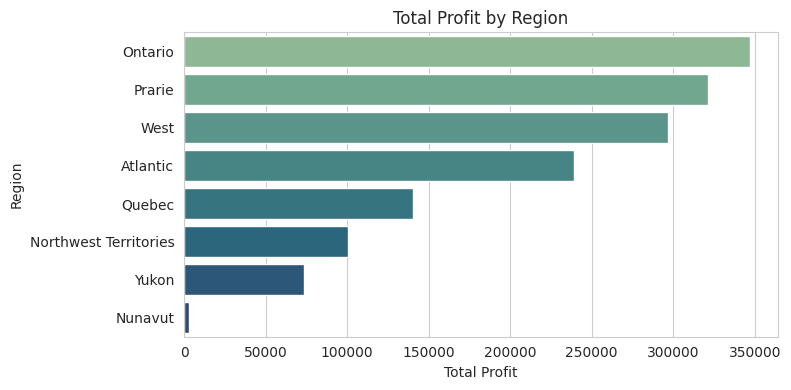

In [3]:
# Question 1: Which regions generate the most and least profit?
region_profit = orders.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print(region_profit)

plt.figure(figsize=(8,4))
sns.barplot(x=region_profit.values, y=region_profit.index, palette="crest")
plt.title("Total Profit by Region")
plt.xlabel("Total Profit")
plt.tight_layout()
plt.show()


**Insight:** Ontario generates the most profit of any region, while Nunavut generates the least, with a gap of well over $300,000 between them - a significant imbalance in regional performance worth investigating further.

### Question 2: Which product category generates the most profit?

In [4]:
# Question 2: Which product category generates the most profit?
category_profit = orders.groupby("Product Category")["Profit"].sum().sort_values(ascending=False)
print(category_profit)


Product Category
Technology         886313.515300
Office Supplies    518021.458000
Furniture          117432.986281
Name: Profit, dtype: float64


**Insight:** Technology is the most profitable category overall (~$886,314), ahead of Office Supplies (~$518,021) and Furniture (~$117,433), which trails far behind the other two.

### Question 3: Which customer segment receives the highest total discount?

In [5]:
# Question 3: Which customer segment receives the highest total discount?
segment_discount = orders.groupby("Customer Segment")["Discount"].sum().sort_values(ascending=False)
print(segment_discount)


Customer Segment
Corporate         153.31
Home Office       100.47
Consumer           82.29
Small Business     81.12
Name: Discount, dtype: float64


**Insight:** The Corporate segment receives the highest cumulative discount (153.31), ahead of Home Office (100.47), Consumer (82.29), and Small Business (81.12). Note: Discount is stored as a rate (e.g. 0.10 = 10%), so this is a sum of rates, not a dollar figure.

### Question 4: Which product category (and sub-category) generates the most losses?

Product Category  Product Sub-Category         
Furniture         Tables                          -99062.529219
                  Bookcases                       -33582.133500
Office Supplies   Scissors, Rulers and Trimmers    -7799.250000
                  Rubber Bands                      -102.670000
                  Storage & Organization            6664.150000
Name: Profit, dtype: float64


/tmp/ipykernel_559/1751335526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=worst5.values, y=[f"{a} / {b}" for a,b in worst5.index], palette="rocket")


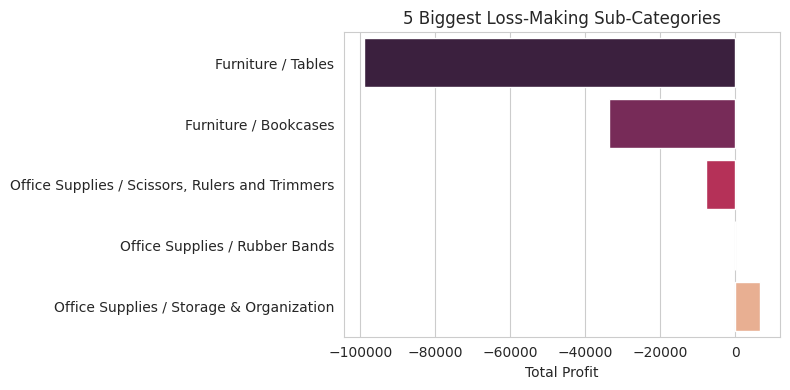

In [6]:
# Question 4: Which product category (and sub-category) generates the most losses?
category_subcat_profit = orders.groupby(["Product Category","Product Sub-Category"])["Profit"].sum().sort_values()
worst5 = category_subcat_profit.head(5)
print(worst5)

plt.figure(figsize=(8,4))
sns.barplot(x=worst5.values, y=[f"{a} / {b}" for a,b in worst5.index], palette="rocket")
plt.title("5 Biggest Loss-Making Sub-Categories")
plt.xlabel("Total Profit")
plt.tight_layout()
plt.show()


**Insight:** Tables, under the Furniture category, is the single biggest loss-making sub-category (-$99,062.53) - despite Furniture as a whole still showing an overall profit, meaning Tables' losses are masked by other Furniture sub-categories. Bookcases (also Furniture) is second-worst at -$33,582.14.

### Question 5: Which ship mode is used most for deliveries?

In [7]:
# Question 5: Which ship mode is used most for deliveries?
ship_mode_count = orders["Ship Mode"].value_counts()
print(ship_mode_count)


Ship Mode
Regular Air       6270
Delivery Truck    1146
Express Air        983
Name: count, dtype: int64


**Insight:** Regular Air is used for the vast majority of deliveries (6,270 orders), far outpacing Delivery Truck (1,146) and Express Air (983).

### Question 6: Which ship mode costs the most on average?

In [8]:
# Question 6: Which ship mode costs the most on average?
ship_mode_cost = orders.groupby("Ship Mode")["Shipping Cost"].mean().sort_values(ascending=False)
print(ship_mode_cost)


Ship Mode
Delivery Truck    45.350733
Express Air        7.986684
Regular Air        7.656809
Name: Shipping Cost, dtype: float64


**Insight:** Delivery Truck costs by far the most per order to ship (~$45.35 average), roughly 5-6 times more expensive than Express Air (~$7.99) or Regular Air (~$7.66) - despite being used the least often.

### Question 7: What is the most profitable individual product?

In [9]:
# Question 7: What is the most profitable individual product?
product_profit = orders.groupby("Product Name")["Profit"].sum().sort_values(ascending=False)
print(product_profit.head(5))


Product Name
Global Troy™ Executive Leather Low-Back Tilter                 79284.780
Hewlett Packard LaserJet 3310 Copier                           73299.600
Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers    55281.390
GBC DocuBind 200 Manual Binding Machine                        50462.515
Canon PC940 Copier                                             47705.836
Name: Profit, dtype: float64

**Insight:** The Global Troy(TM) Executive Leather Low-Back Tilter is the single most profitable product, generating $79,284.78 in total profit, ahead of the Hewlett Packard LaserJet 3310 Copier ($73,299.60).

### Question 8: Which product(s) generate losses?

In [10]:
# Question 8: Which product(s) generate losses?
product_profit_all = orders.groupby("Product Name")["Profit"].sum()
loss_products = product_profit_all[product_profit_all < 0].sort_values()
print(loss_products.head(5))


Product Name
Okidata Pacemark 4410N Wide Format Dot Matrix Printer   -43949.3724
Canon imageCLASS 2200 Advanced Copier                   -31885.6770
Global High-Back Leather Tilter, Burgundy               -30518.9000
Epson DFX-8500 Dot Matrix Printer                       -29400.3450
Hoover Portapower™ Portable Vacuum                      -21088.4800
Name: Profit, dtype: float64


**Insight:** The five biggest loss-making products are: Okidata Pacemark 4410N Wide Format Dot Matrix Printer (-$43,949.37), Canon imageCLASS 2200 Advanced Copier (-$31,885.68), Global High-Back Leather Tilter, Burgundy (-$30,518.90), Epson DFX-8500 Dot Matrix Printer (-$29,400.35), and Hoover Portapower Portable Vacuum (-$21,088.48).

### Question 9: Is there a difference in average profit between orders shipped via different modes?

Ship Mode
Delivery Truck    235.292179
Regular Air       176.187055
Express Air       149.979947
Name: Profit, dtype: float64

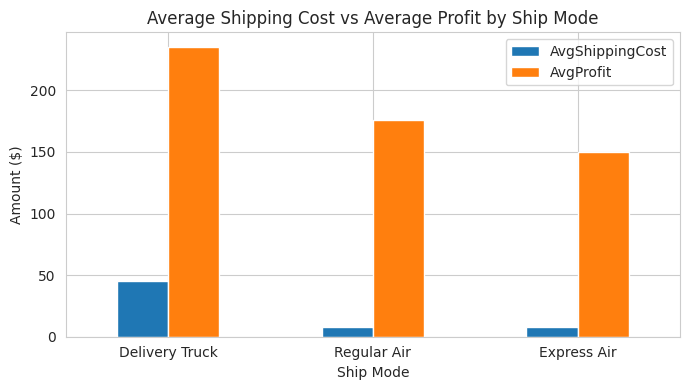

In [11]:
# Question 9: Is there a difference in average profit between orders shipped via different modes?
ship_mode_avg_profit = orders.groupby("Ship Mode")["Profit"].mean().sort_values(ascending=False)
print(ship_mode_avg_profit)

compare = pd.DataFrame({
    "AvgShippingCost": orders.groupby("Ship Mode")["Shipping Cost"].mean(),
    "AvgProfit": orders.groupby("Ship Mode")["Profit"].mean()
}).sort_values("AvgProfit", ascending=False)

compare.plot(kind="bar", figsize=(7,4))
plt.title("Average Shipping Cost vs Average Profit by Ship Mode")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight:** Yes - Delivery Truck orders have the highest average profit per order (~$235.29), despite Delivery Truck also being the most expensive shipping mode (Question 6). This suggests Delivery Truck may be reserved for larger or higher-value orders where the profit margin absorbs the higher shipping cost.

### Question 10: What product category sells the most in each region?

In [12]:
# Question 10: What product category sells the most in each region?
# Pandas equivalent of a SQL window function (ROW_NUMBER() PARTITION BY Region):
# group, sort within each region, then keep only the top row per region.
region_category_sales = orders.groupby(["Region","Product Category"])["Sales"].sum().reset_index()
top_category_per_region = (
    region_category_sales
    .sort_values("Sales", ascending=False)
    .groupby("Region")
    .first()
    .sort_index()
)
print(top_category_per_region[["Product Category","Sales"]])


                      Product Category         Sales
Region                                              
Atlantic                    Technology  8.270570e+05
Northwest Territories       Technology  3.011605e+05
Nunavut                      Furniture  4.354561e+04
Ontario                      Furniture  1.109618e+06
Prarie                      Technology  1.198023e+06
Quebec                       Furniture  6.057841e+05
West                        Technology  1.627049e+06
Yukon                       Technology  4.179911e+05


**Insight:** Technology is the top-selling category by revenue in 6 of the 8 regions, including West, the single highest overall (~$1,627,049). Furniture leads instead in Nunavut and Ontario - notable since Ontario is the most profitable region overall (Question 1), yet Furniture, not Technology, sells best there by revenue.

## 3. Key Takeaways

1. **Profitability is uneven across regions and sub-categories.** Ontario and Technology lead overall, but specific sub-categories like Tables and Bookcases are losing money even within an otherwise profitable category (Furniture).
2. **Shipping strategy doesn't follow cost alone.** Delivery Truck is the most expensive shipping mode, but also the one associated with the highest average profit per order, suggesting it's tied to higher-value shipments rather than being a pure cost center.
3. **Regional buying behavior varies.** While Technology dominates sales in most regions, Ontario and Nunavut are the only two regions where Furniture outsells Technology, despite Ontario being the most profitable region overall.
